In [2]:
import pyedflib
import numpy as np
import matplotlib.pyplot as plt
import mne

# 读取 EDF 文件
edf_file = "chb01_03.edf"
f = pyedflib.EdfReader(edf_file)

# 获取基本信息
n_channels = f.signals_in_file
signal_labels = f.getSignalLabels()
sampling_rate = f.getSampleFrequencies()[0]  # 采样率（一般为 256 Hz）
duration = f.file_duration  # 记录时长（秒）

# 读取所有通道的数据
signals = np.zeros((n_channels, f.getNSamples()[0]))
for i in range(n_channels):
    signals[i, :] = f.readSignal(i)

f.close()

print(f"总通道数: {n_channels}")
print(f"采样率: {sampling_rate} Hz")
print(f"记录时长: {duration} 秒")
print(f"通道名称: {signal_labels}")


总通道数: 23
采样率: 256.0 Hz
记录时长: 3600.0 秒
通道名称: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8']


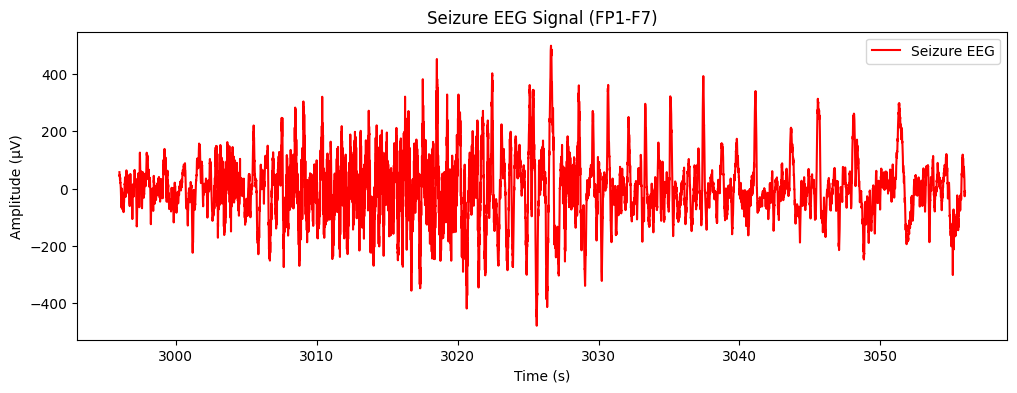

In [3]:
# 癫痫时间段（单位：采样点）
start_sample = int(2996 * sampling_rate)
end_sample = int(3056 * sampling_rate)

# 选取一个主要 EEG 通道，比如 "FP1-F7"
channel_index = signal_labels.index("FP1-F7")
seizure_signal = signals[channel_index, start_sample:end_sample]

# 生成时间轴
time = np.linspace(2996, 3056, len(seizure_signal))

# 绘制癫痫片段信号
plt.figure(figsize=(12, 4))
plt.plot(time, seizure_signal, color='red', label="Seizure EEG")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title("Seizure EEG Signal (FP1-F7)")
plt.legend()
plt.show()


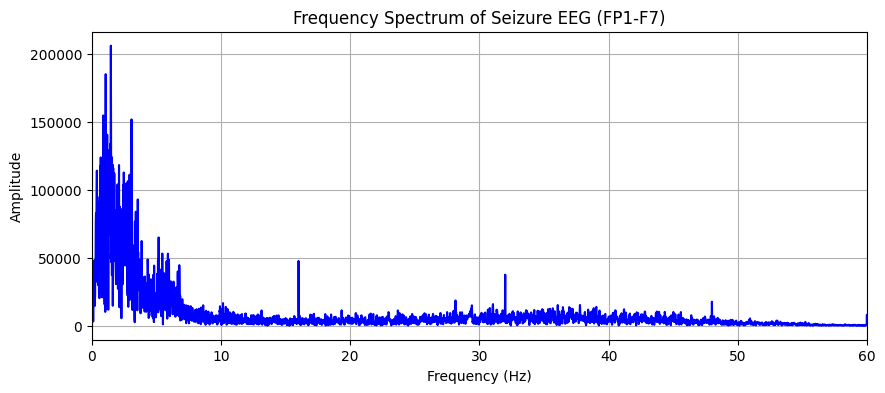

In [5]:
from scipy.fftpack import fft

# 计算 FFT
N = len(seizure_signal)
freqs = np.fft.fftfreq(N, d=1/sampling_rate)  # 计算频率轴
fft_values = np.abs(fft(seizure_signal))  # 计算幅值

# 只绘制 0-60Hz 频段
plt.figure(figsize=(10, 4))
plt.plot(freqs[:N//2], fft_values[:N//2], color='blue')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency Spectrum of Seizure EEG (FP1-F7)")
plt.xlim(0, 60)  # 只显示 0-60Hz
plt.grid()
plt.show()


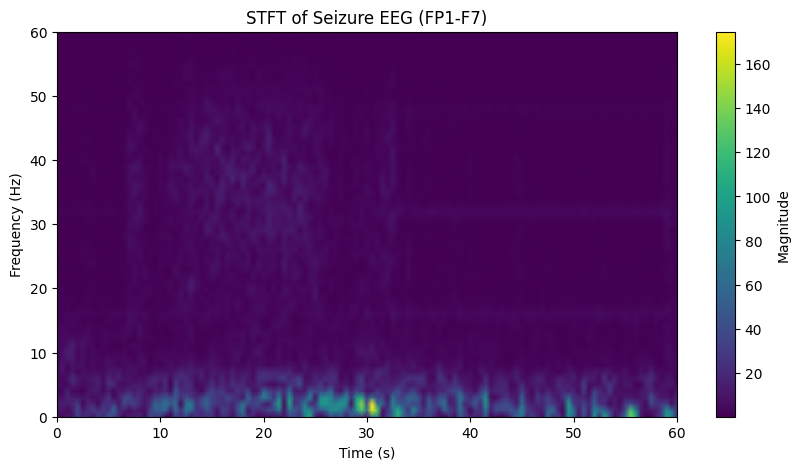

In [6]:
import scipy.signal as signal

# 计算 STFT
f, t, Zxx = signal.stft(seizure_signal, fs=sampling_rate, nperseg=256)

plt.figure(figsize=(10, 5))
plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
plt.colorbar(label="Magnitude")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("STFT of Seizure EEG (FP1-F7)")
plt.ylim(0, 60)  # 关注 0-60Hz
plt.show()


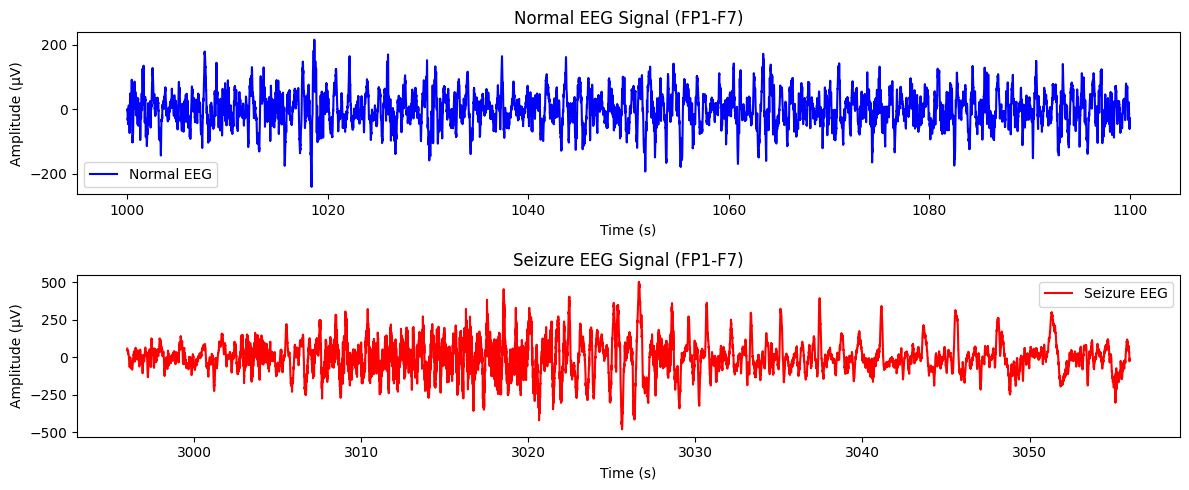

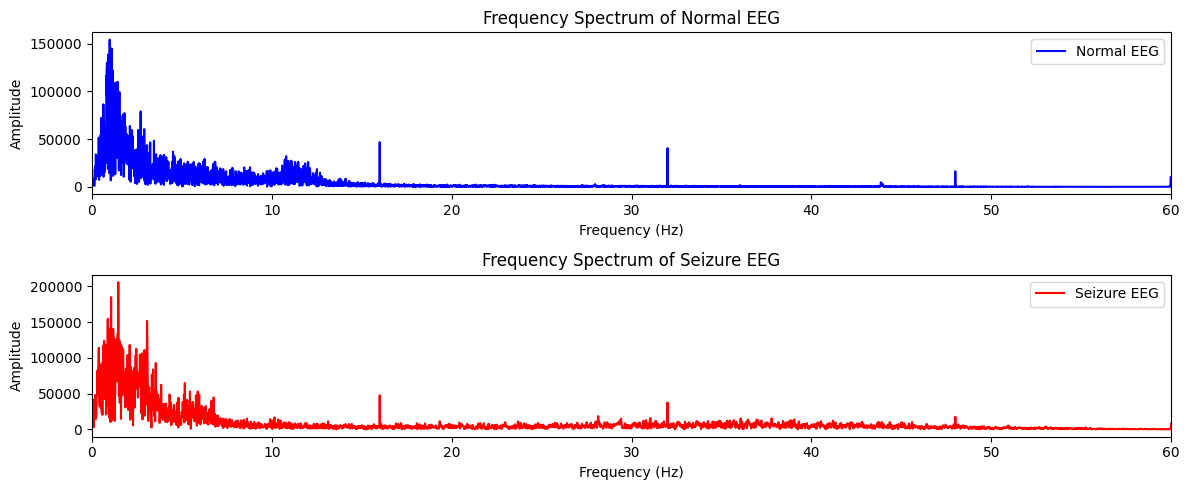

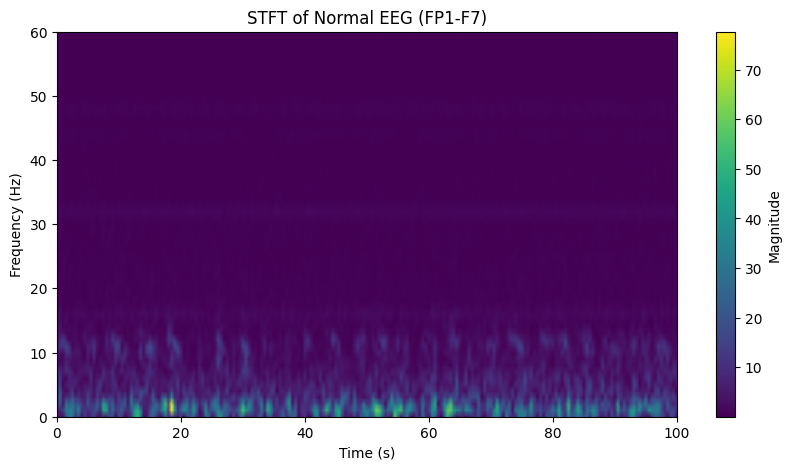

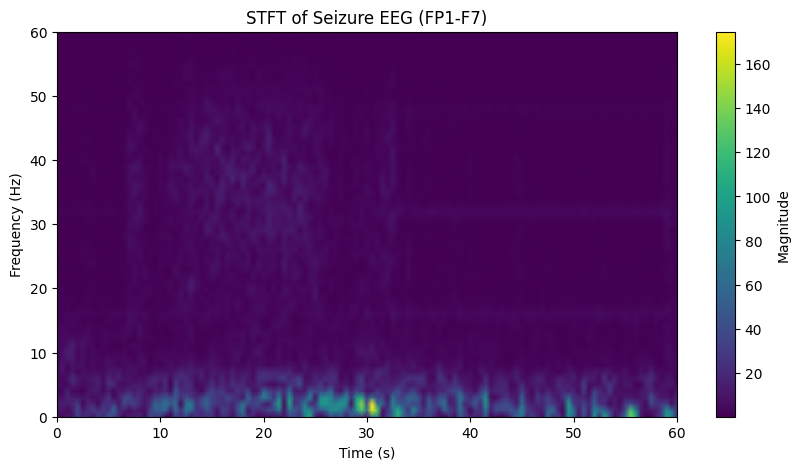

In [8]:
import pyedflib
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.fftpack import fft
from scipy.signal import stft  # 确保导入 STFT 函数

# 读取 EDF 文件
edf_file = "chb01_03.edf"
f = pyedflib.EdfReader(edf_file)

# 获取通道信息
signal_labels = f.getSignalLabels()
sampling_rate = f.getSampleFrequencies()[0]  # 采样率（通常为 256Hz）

# 读取所有通道的数据
n_channels = f.signals_in_file
signals = np.zeros((n_channels, f.getNSamples()[0]))
for i in range(n_channels):
    signals[i, :] = f.readSignal(i)

f.close()

# 选择 EEG 主要通道（如 "FP1-F7"）
channel_index = signal_labels.index("FP1-F7")

# 定义时间段（单位：秒）
seizure_start, seizure_end = 2996, 3056
normal_start, normal_end = 1000, 1100

# 转换为采样点
seizure_start_sample, seizure_end_sample = int(seizure_start * sampling_rate), int(seizure_end * sampling_rate)
normal_start_sample, normal_end_sample = int(normal_start * sampling_rate), int(normal_end * sampling_rate)

# 提取信号
seizure_signal = signals[channel_index, seizure_start_sample:seizure_end_sample]
normal_signal = signals[channel_index, normal_start_sample:normal_end_sample]

# 生成时间轴
seizure_time = np.linspace(seizure_start, seizure_end, len(seizure_signal))
normal_time = np.linspace(normal_start, normal_end, len(normal_signal))

# -------------------- 时域分析 --------------------
plt.figure(figsize=(12, 5))
plt.subplot(2, 1, 1)
plt.plot(normal_time, normal_signal, label="Normal EEG", color='blue')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title("Normal EEG Signal (FP1-F7)")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(seizure_time, seizure_signal, label="Seizure EEG", color='red')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title("Seizure EEG Signal (FP1-F7)")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------- 频域分析（FFT） --------------------
def compute_fft(signal, sampling_rate):
    """计算 FFT 并返回频率和幅度"""
    N = len(signal)
    freqs = np.fft.fftfreq(N, d=1/sampling_rate)  # 计算频率轴
    fft_values = np.abs(fft(signal))  # 计算幅值
    return freqs[:N//2], fft_values[:N//2]  # 只取正频率部分

# 计算 FFT
freqs_normal, fft_normal = compute_fft(normal_signal, sampling_rate)
freqs_seizure, fft_seizure = compute_fft(seizure_signal, sampling_rate)

plt.figure(figsize=(12, 5))
plt.subplot(2, 1, 1)
plt.plot(freqs_normal, fft_normal, color='blue', label="Normal EEG")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency Spectrum of Normal EEG")
plt.xlim(0, 60)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(freqs_seizure, fft_seizure, color='red', label="Seizure EEG")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency Spectrum of Seizure EEG")
plt.xlim(0, 60)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------- 时频分析（STFT） --------------------from scipy.signal import stft  # 确保导入 STFT 函数

def plot_stft(eeg_signal, sampling_rate, title):
    """绘制 STFT 时频图"""
    f, t, Zxx = stft(eeg_signal, fs=sampling_rate, nperseg=256)  # 修正错误
    plt.figure(figsize=(10, 5))
    plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
    plt.colorbar(label="Magnitude")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(title)
    plt.ylim(0, 60)  # 关注 0-60Hz 频率范围
    plt.show()

# 重新调用绘图函数
plot_stft(normal_signal, sampling_rate, "STFT of Normal EEG (FP1-F7)")
plot_stft(seizure_signal, sampling_rate, "STFT of Seizure EEG (FP1-F7)")



d:\Users\epiph\anaconda3\Lib\site-packages\pywt\_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should takethe form cmorB-C where B and C are floats representing the bandwidth frequency and center frequency, respectively (example: cmor1.5-1.0).
  wavelet = DiscreteContinuousWavelet(wavelet)


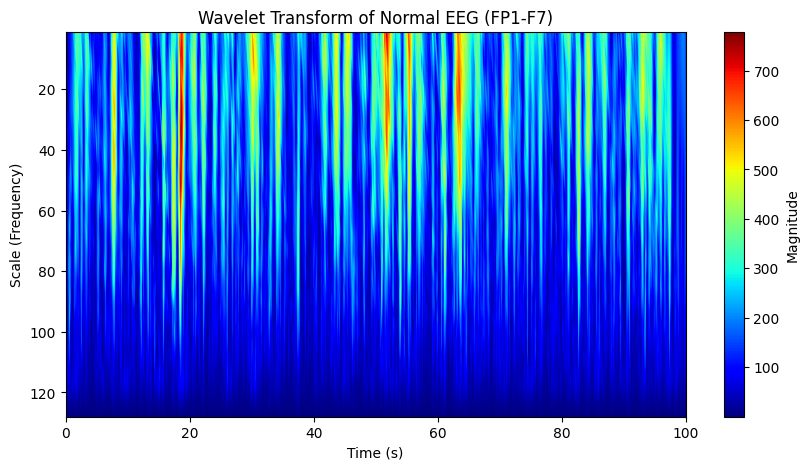

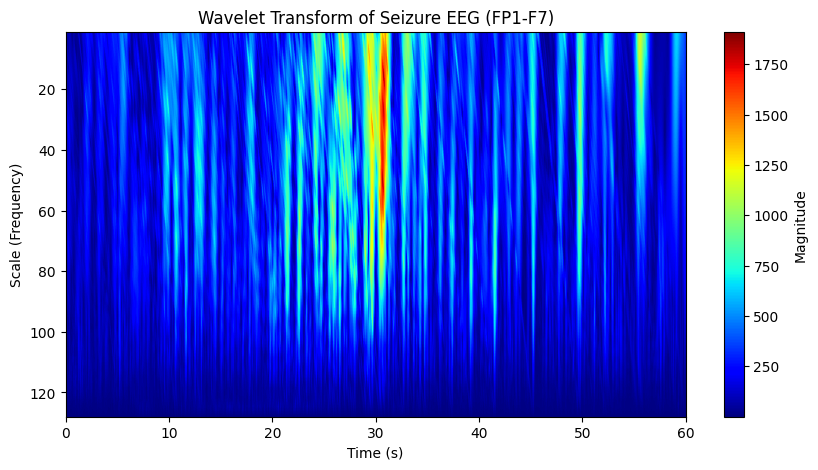

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

def plot_wavelet_transform(eeg_signal, sampling_rate, title):
    """绘制 EEG 信号的小波变换时频图"""
    scales = np.arange(1, 128)  # 设定小波尺度范围（对应不同的频率）
    wavelet = 'cmor'  # 选用复 Morlet 小波
    coefficients, frequencies = pywt.cwt(eeg_signal, scales, wavelet, sampling_period=1/sampling_rate)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(np.abs(coefficients), aspect='auto', extent=[0, len(eeg_signal)/sampling_rate, 1, 128], cmap='jet')
    plt.colorbar(label="Magnitude")
    plt.xlabel("Time (s)")
    plt.ylabel("Scale (Frequency)")
    plt.title(title)
    plt.gca().invert_yaxis()  # 让高频在顶部，低频在底部
    plt.show()

# 计算小波变换并绘图
plot_wavelet_transform(normal_signal, sampling_rate, "Wavelet Transform of Normal EEG (FP1-F7)")
plot_wavelet_transform(seizure_signal, sampling_rate, "Wavelet Transform of Seizure EEG (FP1-F7)")
